In [3]:
# Cell 1: Import Libraries
# ====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [4]:
# Cell 2: Load & Clean Dataset
# ====================================================
df = pd.read_csv("Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

print("Dataset shape:", df.shape)
print("Class distribution:\n", df['Churn'].value_counts(normalize=True))

Dataset shape: (7032, 20)
Class distribution:
 Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [5]:
# Cell 3: Train/Test Split
# ====================================================
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify categorical features
cat_features = X.select_dtypes(include=['object']).columns.tolist()
cat_indices = [X.columns.get_loc(col) for col in cat_features]

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
# Cell 4: CatBoost Model Training
# ====================================================
# Calculate class weight
pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

cat_model = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    class_weights=[1.0, pos_weight],
    verbose=0
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_indices,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    use_best_model=True
)

CatBoostClassifier(class_weights=[1.0, 2.762541806020067], depth=6, eval_metric='AUC', iterations=800, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=0)

In [7]:
# Cell 5: CatBoost Predictions & Metrics
# ====================================================
y_pred_cat = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

# Metrics
acc_cat = accuracy_score(y_test, y_pred_cat)
auc_cat = roc_auc_score(y_test, y_proba_cat)
f1_cat = f1_score(y_test, y_pred_cat)
pr_auc_cat = average_precision_score(y_test, y_proba_cat)

print("\n===== CatBoost Performance =====")
print("Accuracy :", round(acc_cat, 4))
print("ROC-AUC  :", round(auc_cat, 4))
print("PR-AUC   :", round(pr_auc_cat, 4))
print("F1-Score :", round(f1_cat, 4))


===== CatBoost Performance =====
Accuracy : 0.7328
ROC-AUC  : 0.8395
PR-AUC   : 0.6594
F1-Score : 0.6155


In [8]:
# Cell 6: Manual Cross Validation
# ====================================================
print("\nRunning Manual Cross Validation...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    
    model_cv = CatBoostClassifier(
        iterations=800,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        random_state=42,
        verbose=0
    )
    
    model_cv.fit(
        X_train_cv,
        y_train_cv,
        cat_features=cat_indices
    )
    
    y_val_proba = model_cv.predict_proba(X_val_cv)[:, 1]
    fold_auc = roc_auc_score(y_val_cv, y_val_proba)
    
    cv_auc_scores.append(fold_auc)
    print(f"Fold {fold+1} AUC: {round(fold_auc,4)}")

print("\nMean CV AUC:", round(np.mean(cv_auc_scores),4))
print("Std CV AUC :", round(np.std(cv_auc_scores),4))


Running Manual Cross Validation...
Fold 1 AUC: 0.8407
Fold 2 AUC: 0.8545
Fold 3 AUC: 0.8429
Fold 4 AUC: 0.8382
Fold 5 AUC: 0.8363

Mean CV AUC: 0.8425
Std CV AUC : 0.0064


In [9]:
# Cell 7: Threshold Optimization
# ====================================================
thresholds = np.linspace(0.1, 0.9, 100)
f1_scores = []

for t in thresholds:
    preds = (y_proba_cat >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print("\nBest Threshold (F1 Optimized):", round(best_threshold,3))


Best Threshold (F1 Optimized): 0.625


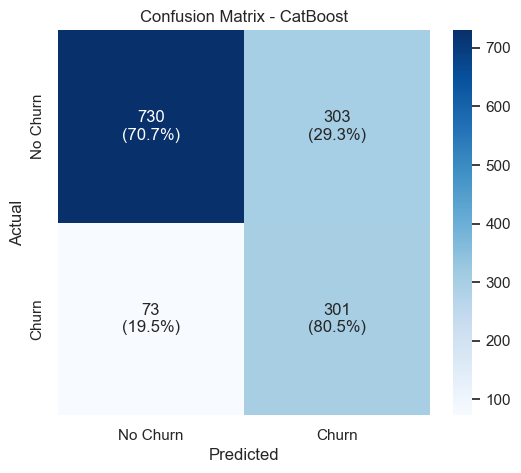

In [10]:
# Cell 8: Confusion Matrix (Advanced)
# ====================================================
cm = confusion_matrix(y_test, y_pred_cat)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = np.array([
    [f"{cm[i][j]}\n({cm_percent[i][j]:.1%})"
     for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"])
plt.title("Confusion Matrix - CatBoost")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

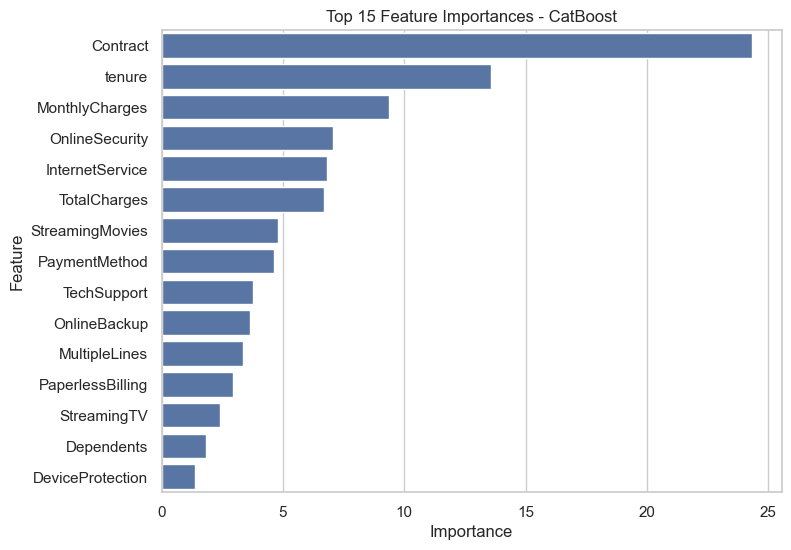

In [11]:
# Cell 9: Feature Importance
# ====================================================
importances = cat_model.get_feature_importance()
fi_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=fi_df, x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - CatBoost")
plt.show()

In [12]:
# Cell 10: Logistic Regression Training
# ====================================================
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:,1]

acc_log = accuracy_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_proba_log)
f1_log = f1_score(y_test, y_pred_log)
pr_auc_log = average_precision_score(y_test, y_proba_log)

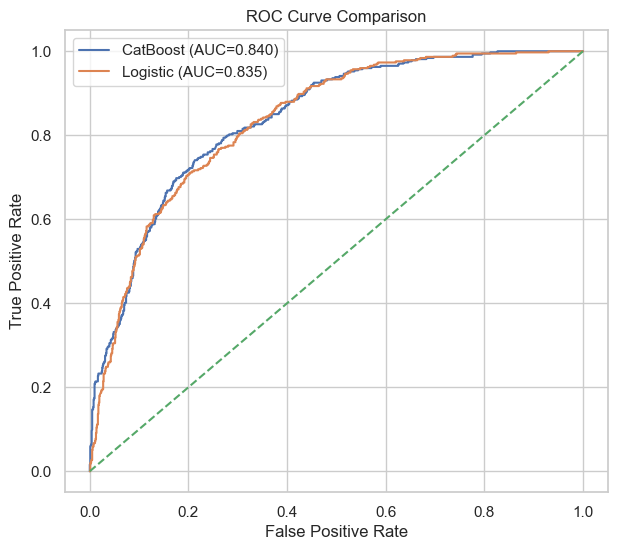

In [13]:
# Cell 11: ROC Curve Comparison
# ====================================================
plt.figure(figsize=(7,6))

fpr_cat, tpr_cat, _ = roc_curve(y_test, y_proba_cat)
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)

plt.plot(fpr_cat, tpr_cat, label=f"CatBoost (AUC={auc_cat:.3f})")
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={auc_log:.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

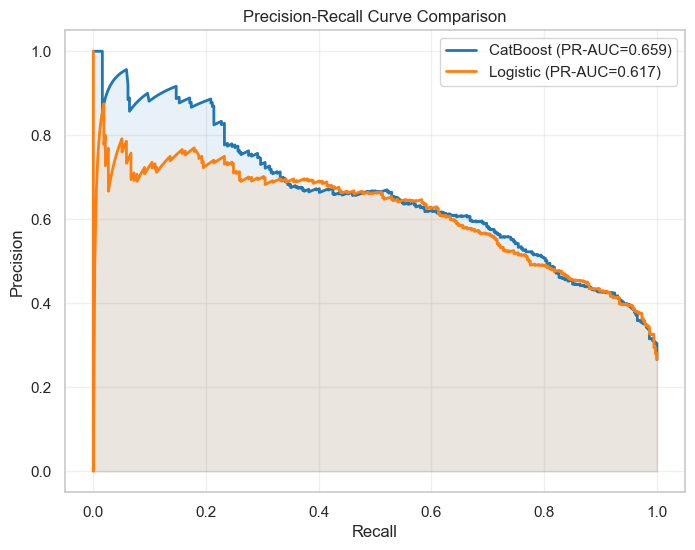

In [16]:
# Precision-Recall Curve Comparison (Corrected)
from sklearn.metrics import precision_recall_curve, average_precision_score

# CatBoost
prec_cat, rec_cat, _ = precision_recall_curve(y_test, y_proba_cat)
pr_auc_cat = average_precision_score(y_test, y_proba_cat)

# Logistic Regression
prec_log, rec_log, _ = precision_recall_curve(y_test, y_proba_log)
pr_auc_log = average_precision_score(y_test, y_proba_log)

# Plot
plt.figure(figsize=(8,6))
plt.plot(rec_cat, prec_cat, label=f"CatBoost (PR-AUC={pr_auc_cat:.3f})", color="#1f77b4", linewidth=2)
plt.plot(rec_log, prec_log, label=f"Logistic (PR-AUC={pr_auc_log:.3f})", color="#ff7f0e", linewidth=2)
plt.fill_between(rec_cat, prec_cat, alpha=0.1, color="#1f77b4")
plt.fill_between(rec_log, prec_log, alpha=0.1, color="#ff7f0e")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
# Cell 13: Final Model Comparison Table
# ====================================================
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "CatBoost"],
    "Accuracy": [acc_log, acc_cat],
    "ROC-AUC": [auc_log, auc_cat],
    "PR-AUC": [pr_auc_log, pr_auc_cat],
    "F1-Score": [f1_log, f1_cat]
})

print("\n===== Final Model Comparison =====")
print(comparison)


===== Final Model Comparison =====
                 Model  Accuracy   ROC-AUC    PR-AUC  F1-Score
0  Logistic Regression  0.726368  0.834977  0.617349  0.607543
1             CatBoost  0.732765  0.839507  0.659379  0.615542
